# Machine Learning Assignment  -2
# Student ID :  2025AA05921
# Name : Kamaraj

# Loan Approval Classification - Model - 2 - Decision Tree

In [1]:
# Import the required libraries 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns  
from sklearn.model_selection import train_test_split, cross_val_score 
from sklearn.preprocessing import LabelEncoder  
from sklearn.tree import DecisionTreeClassifier 
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, matthews_corrcoef, precision_score, recall_score, f1_score, confusion_matrix, roc_curve  
import warnings  
warnings.filterwarnings('ignore')  
import joblib
import os
from sklearn.metrics import confusion_matrix

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print(f"Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Step 1: Data Loading
# Read the dataset
train_data = pd.read_csv('../data/train_data.csv')
test_data = pd.read_csv('../data/test_data.csv')

print(f"Training data loaded: {train_data.shape}")
print(f"Test data loaded: {test_data.shape}")

# Combine the data for preprocessing and analysis
df_raw = pd.concat([train_data, test_data], ignore_index=True)

print(f"\nCombined dataset shape: {df_raw.shape}")
print(f"Columns: {list(df_raw.columns)}")
print("\nFirst few rows:")
print(df_raw.head())


Training data loaded: (33750, 14)
Test data loaded: (11250, 14)

Combined dataset shape: (45000, 14)
Columns: ['person_age', 'person_gender', 'person_education', 'person_income', 'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'previous_loan_defaults_on_file', 'loan_status']

First few rows:
   person_age person_gender person_education  person_income  person_emp_exp  \
0        26.0        female        Associate       102675.0               5   
1        24.0          male         Bachelor        84036.0               0   
2        24.0        female         Bachelor        68237.0               2   
3        25.0        female        Associate        69530.0               0   
4        37.0        female        Associate       120992.0              12   

  person_home_ownership  loan_amnt        loan_intent  loan_int_rate  \
0              MORTGAGE     6000.0          EDUCATI

In [3]:
# Step 2:  EDA 
print("Dataset Information:")
print(df_raw.info())

print("\nTarget Variable Distribution:")
print(df_raw['loan_status'].value_counts())
print(f"Class Balance: {df_raw['loan_status'].value_counts(normalize=True).round(4)}") # Class  Distribution

print("\nMissing Values:")
print(df_raw.isnull().sum()) # Ensures that we have no missing values in the dataset

print("\nBasic Statistics:")
print(df_raw.describe())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_lo

In [4]:
# Step 3: Data Preprocessing - Categorical Encoding

df = df_raw.copy()  # Work on a copy to preserve the original

categorical_cols = [  # List of categorical columns
    'person_gender',
    'person_education',
    'person_home_ownership',
    'loan_intent',
    'previous_loan_defaults_on_file'
]


# Store label encoders for each categorical column
label_encoders = {}

for col in categorical_cols:  # Loop through categorical columns
    if col in df.columns:
        print(f"Encoding {col}:")
        print(f"  Original values: {df[col].unique()}")
        
        le = LabelEncoder()  # Initialize label encoder
        df[col] = le.fit_transform(df[col].astype(str))  # Encode categories as integers
        label_encoders[col] = le  # Store the encoder
        
        print(f"  Encoded values: {df[col].unique()}")


# Now encode the actual train and test data 
df_train = train_data.copy()
df_test = test_data.copy()

for col in categorical_cols:
    if col in df_train.columns:
        le = LabelEncoder()
        df_train[col] = le.fit_transform(df_train[col].astype(str))
        df_test[col] = le.transform(df_test[col].astype(str))


Encoding person_gender:
  Original values: ['female' 'male']
  Encoded values: [0 1]
Encoding person_education:
  Original values: ['Associate' 'Bachelor' 'High School' 'Master' 'Doctorate']
  Encoded values: [0 1 3 4 2]
Encoding person_home_ownership:
  Original values: ['MORTGAGE' 'RENT' 'OWN' 'OTHER']
  Encoded values: [0 3 2 1]
Encoding loan_intent:
  Original values: ['EDUCATION' 'DEBTCONSOLIDATION' 'MEDICAL' 'HOMEIMPROVEMENT' 'VENTURE'
 'PERSONAL']
  Encoded values: [1 0 3 2 5 4]
Encoding previous_loan_defaults_on_file:
  Original values: ['No' 'Yes']
  Encoded values: [0 1]


In [5]:
# Step 4: Feature and Target variables separation

X = df.drop('loan_status', axis=1)  # Feature matrix
y = df['loan_status']  # Target variable


print(f"Feature matrix X shape: {X.shape}")
print(f"Target vector y shape: {y.shape}")
print(f"Features: {list(X.columns)}")
print(f"Target classes: {y.unique()}")
print(f"Target distribution: {y.value_counts().to_dict()}")


Feature matrix X shape: (45000, 13)
Target vector y shape: (45000,)
Features: ['person_age', 'person_gender', 'person_education', 'person_income', 'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'previous_loan_defaults_on_file']
Target classes: [0 1]
Target distribution: {0: 35000, 1: 10000}


In [6]:
# Step 5: Prepare Features and Targets from Encoded Data

print("Preparing Features and Targets from Encoded Data:")
print("=" * 60)

# Separate features and target from training data
X_train = df_train.drop('loan_status', axis=1)
y_train = df_train['loan_status']

# Separate features and target from test data
X_test = df_test.drop('loan_status', axis=1)
y_test = df_test['loan_status']

print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/(X_train.shape[0]+X_test.shape[0])*100:.1f}%)")
print(f"Test set: {X_test.shape[0]} samples ({X_test.shape[0]/(X_train.shape[0]+X_test.shape[0])*100:.1f}%)")
print(f"Training features shape: {X_train.shape}")
print(f"Test features shape: {X_test.shape}")

print("\nClass distribution in training set:")
print(y_train.value_counts())
print(f"Training class balance: {y_train.value_counts(normalize=True).round(4)}")

print("\nClass distribution in test set:")
print(y_test.value_counts())
print(f"Test class balance: {y_test.value_counts(normalize=True).round(4)}")



Preparing Features and Targets from Encoded Data:
Training set: 33750 samples (75.0%)
Test set: 11250 samples (25.0%)
Training features shape: (33750, 13)
Test features shape: (11250, 13)

Class distribution in training set:
loan_status
0    26250
1     7500
Name: count, dtype: int64
Training class balance: loan_status
0    0.7778
1    0.2222
Name: proportion, dtype: float64

Class distribution in test set:
loan_status
0    8750
1    2500
Name: count, dtype: int64
Test class balance: loan_status
0    0.7778
1    0.2222
Name: proportion, dtype: float64


In [7]:
# Step 6: Model Training - Decision Tree Classifier

model = DecisionTreeClassifier(
    random_state=42,        
    max_depth=10,          # Limit tree depth to prevent overfitting
    min_samples_split=20,  # Minimum samples required to split a node
    min_samples_leaf=10    # Minimum samples required at leaf node
)

# Train the model
model.fit(X_train, y_train)

print("Model training completed!")
print(f"Tree depth: {model.tree_.max_depth}")
print(f"Number of leaves: {model.tree_.n_leaves}")
print(f"Number of nodes: {model.tree_.node_count}")

# Display feature importance
feature_importance = model.feature_importances_
print(f"\nTop 5 Most Important Features:")
feature_names = X.columns
sorted_idx = np.argsort(feature_importance)[::-1]
for i in range(min(5, len(feature_names))):
    feature = feature_names[sorted_idx[i]]
    importance = feature_importance[sorted_idx[i]]
    print(f"  {i+1}. {feature}: {importance:.4f}")

Model training completed!
Tree depth: 10
Number of leaves: 184
Number of nodes: 367

Top 5 Most Important Features:
  1. previous_loan_defaults_on_file: 0.4192
  2. loan_percent_income: 0.1865
  3. loan_int_rate: 0.1864
  4. person_income: 0.0950
  5. person_home_ownership: 0.0560


In [8]:
# Step 7: Model Predictions
y_pred = model.predict(X_test)  # Predicted class labels (0/1)
y_prob = model.predict_proba(X_test)[:, 1]  # Probability of class 1 (approved)

print("Predictions Generated:")
print(f"Number of test samples: {len(y_test)}")
print(f"Number of predictions: {len(y_pred)}")

#  prediction distribution
unique, counts = np.unique(y_pred, return_counts=True)
print(f"\nPrediction Distribution:")
for val, count in zip(unique, counts):
    print(f"  Class {val}: {count} predictions ({count/len(y_pred)*100:.1f}%)")


Predictions Generated:
Number of test samples: 11250
Number of predictions: 11250

Prediction Distribution:
  Class 0: 9253 predictions (82.2%)
  Class 1: 1997 predictions (17.8%)


In [9]:
# Step 8: Model Evaluation - Core Metrics

print("Model Evaluation - Core Metrics - Decision Tree:")

# 1. Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"1. Accuracy: {accuracy:.4f}")

# 2. AUC Score
auc = roc_auc_score(y_test, y_prob)
print(f"2. AUC Score: {auc:.4f}")

# 3. Precision
precision = precision_score(y_test, y_pred, average='weighted')
print(f"3. Precision: {precision:.4f}")

# 4. Recall
recall = recall_score(y_test, y_pred, average='weighted')
print(f"4. Recall: {recall:.4f}")

# 5. F1 Score
f1 = f1_score(y_test, y_pred, average='weighted')
print(f"5. F1 Score: {f1:.4f}")

# 6. Matthews Correlation Coefficient (MCC)
mcc = matthews_corrcoef(y_test, y_pred)
print(f"6. MCC Score: {mcc:.4f}")


Model Evaluation - Core Metrics - Decision Tree:
1. Accuracy: 0.9160
2. AUC Score: 0.9600
3. Precision: 0.9146
4. Recall: 0.9160
5. F1 Score: 0.9125
6. MCC Score: 0.7455


In [10]:
# Step 9: Classification Report (Additional Analysis)
# Detailed per-class performance analysis
print(" CLASSIFICATION REPORT")
print(classification_report(y_test, y_pred, target_names=['Rejected (0)', 'Approved (1)']))

# Confusion Matrix Analysis

cm = confusion_matrix(y_test, y_pred)

print("\nCONFUSION MATRIX")
print("=" * 20)
print("Actual\\Predicted    0     1")
print(f"0 (Rejected)     {cm[0,0]:4d}  {cm[0,1]:4d}")
print(f"1 (Approved)     {cm[1,0]:4d}  {cm[1,1]:4d}")

print("=" * 20)
# Calculate True/False Positives/Negatives
tn, fp, fn, tp = cm.ravel()
print(f"Confusion Matrix Components:")
print(f"True Negatives (TN):  {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP):  {tp}")


 CLASSIFICATION REPORT
              precision    recall  f1-score   support

Rejected (0)       0.92      0.97      0.95      8750
Approved (1)       0.89      0.71      0.79      2500

    accuracy                           0.92     11250
   macro avg       0.91      0.84      0.87     11250
weighted avg       0.91      0.92      0.91     11250


CONFUSION MATRIX
Actual\Predicted    0     1
0 (Rejected)     8529   221
1 (Approved)      724  1776
Confusion Matrix Components:
True Negatives (TN):  8529
False Positives (FP): 221
False Negatives (FN): 724
True Positives (TP):  1776


MODEL VISUALIZATIONS


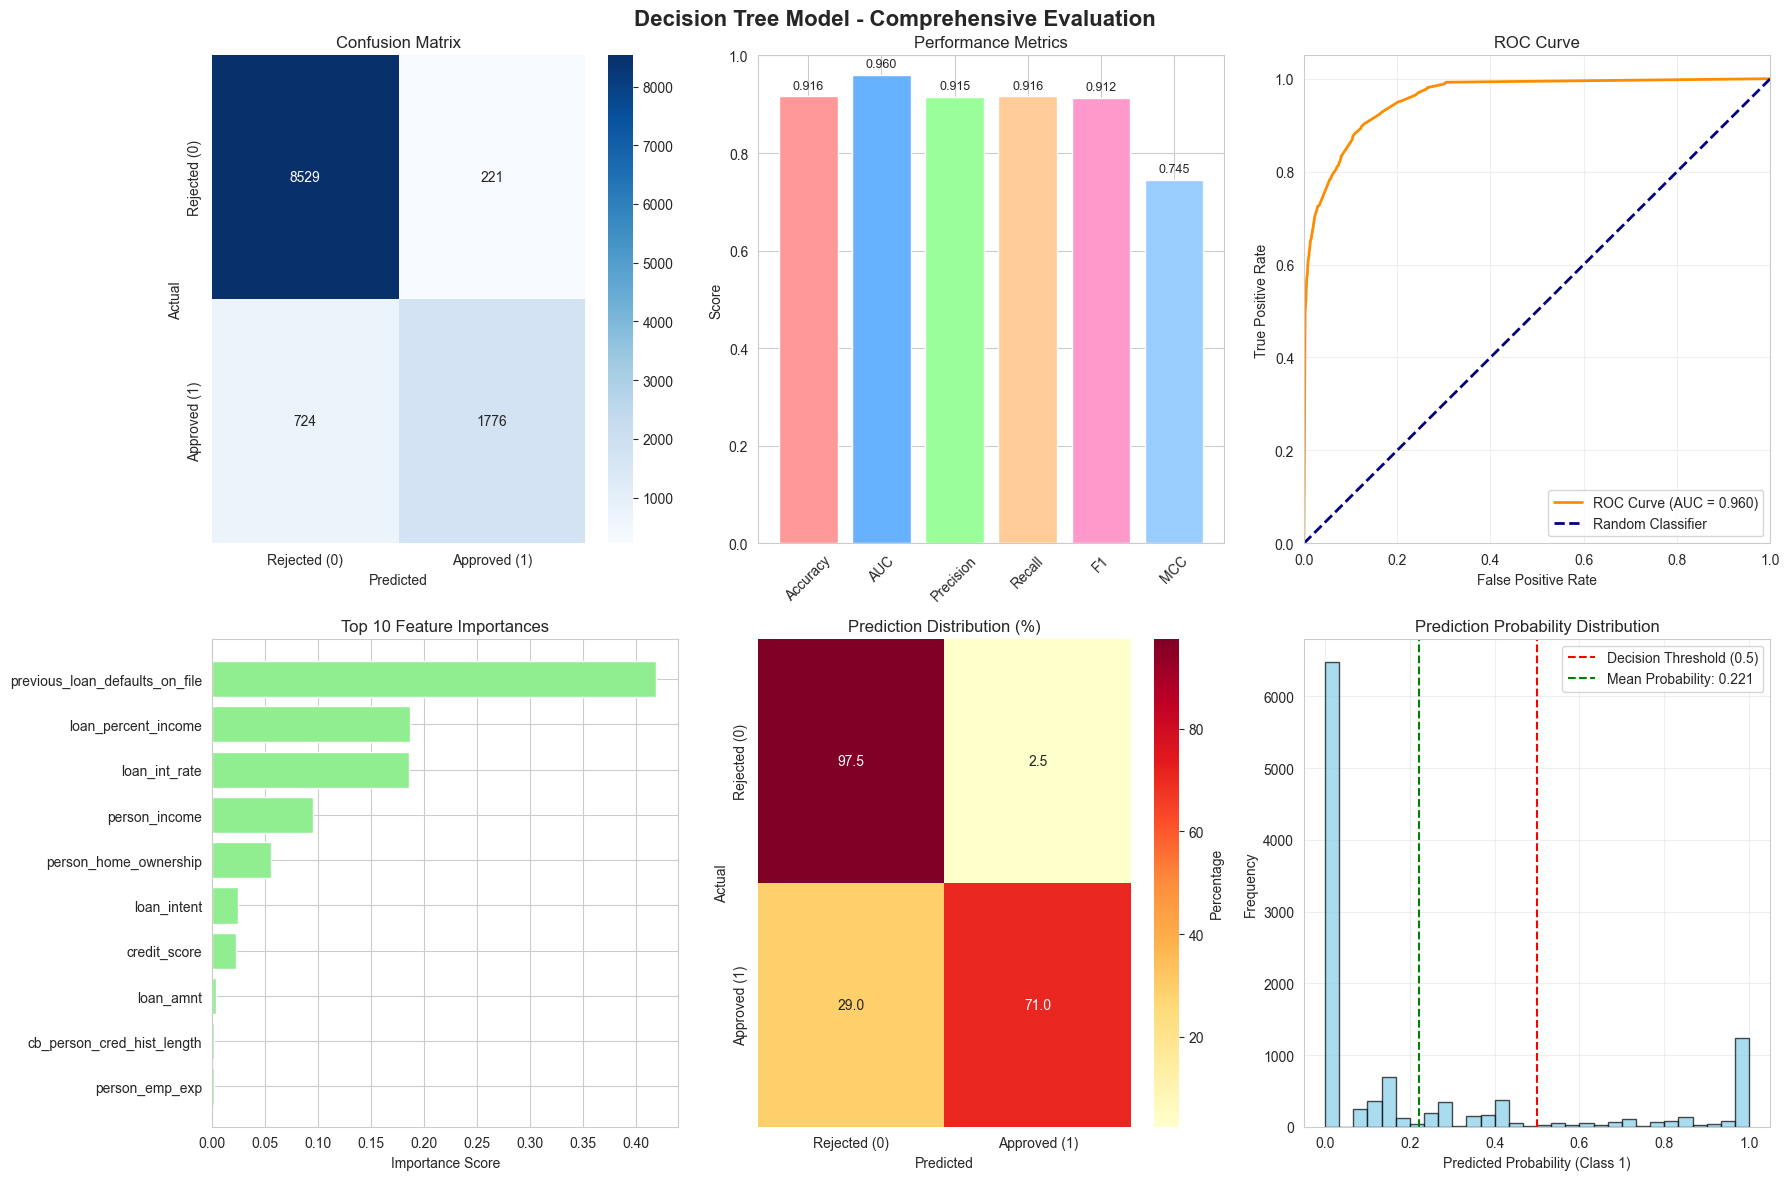

In [11]:
# Step 10: Model  Visualizations

print("MODEL VISUALIZATIONS")

# Create figure with subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Decision Tree Model - Comprehensive Evaluation', fontsize=16, fontweight='bold')

# 1. Confusion Matrix 
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Rejected (0)', 'Approved (1)'], 
            yticklabels=['Rejected (0)', 'Approved (1)'], ax=axes[0,0])
axes[0,0].set_title('Confusion Matrix')
axes[0,0].set_ylabel('Actual')
axes[0,0].set_xlabel('Predicted')

# 2. Metrics Comparison
metrics_names = ['Accuracy', 'AUC', 'Precision', 'Recall', 'F1', 'MCC']
metrics_values = [accuracy, auc, precision, recall, f1, mcc]
bars = axes[0,1].bar(metrics_names, metrics_values, color=['#FF9999', '#66B2FF', '#99FF99', '#FFCC99', '#FF99CC', '#99CCFF'])
axes[0,1].set_title('Performance Metrics')
axes[0,1].set_ylabel('Score')
axes[0,1].set_ylim(0, 1)
axes[0,1].tick_params(axis='x', rotation=45)
for i, bar in enumerate(bars):
    height = bar.get_height()
    axes[0,1].text(bar.get_x() + bar.get_width()/2., height + 0.01, f'{metrics_values[i]:.3f}', 
                   ha='center', va='bottom', fontsize=9)

# 3. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[0,2].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {auc:.3f})')
axes[0,2].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
axes[0,2].set_xlim([0.0, 1.0])
axes[0,2].set_ylim([0.0, 1.05])
axes[0,2].set_xlabel('False Positive Rate')
axes[0,2].set_ylabel('True Positive Rate')
axes[0,2].set_title('ROC Curve')
axes[0,2].legend(loc="lower right")
axes[0,2].grid(True, alpha=0.3)

# 4. Feature Importance (Top 10)
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)
importance_df_top10 = importance_df.head(10)
axes[1,0].barh(range(len(importance_df_top10)), importance_df_top10['Importance'], color='lightgreen')
axes[1,0].set_yticks(range(len(importance_df_top10)))
axes[1,0].set_yticklabels(importance_df_top10['Feature'])
axes[1,0].set_title('Top 10 Feature Importances')
axes[1,0].set_xlabel('Importance Score')
axes[1,0].invert_yaxis()

# 5. Prediction Distribution
pred_df = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred})
pred_crosstab = pd.crosstab(pred_df['Actual'], pred_df['Predicted'], normalize='index') * 100
sns.heatmap(pred_crosstab, annot=True, fmt='.1f', cmap='YlOrRd', 
            xticklabels=['Rejected (0)', 'Approved (1)'], 
            yticklabels=['Rejected (0)', 'Approved (1)'], ax=axes[1,1], cbar_kws={'label': 'Percentage'})
axes[1,1].set_title('Prediction Distribution (%)')
axes[1,1].set_ylabel('Actual')
axes[1,1].set_xlabel('Predicted')

# 6. Prediction Probability Distribution
axes[1,2].hist(y_prob, bins=30, color='skyblue', alpha=0.7, edgecolor='black')
axes[1,2].axvline(0.5, color='red', linestyle='--', label='Decision Threshold (0.5)')
axes[1,2].axvline(np.mean(y_prob), color='green', linestyle='--', label=f'Mean Probability: {np.mean(y_prob):.3f}')
axes[1,2].set_title('Prediction Probability Distribution')
axes[1,2].set_xlabel('Predicted Probability (Class 1)')
axes[1,2].set_ylabel('Frequency')
axes[1,2].legend()
axes[1,2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [12]:
# Step 11: Summary

results_summary = {
    'ML Model Name': '2. Decision Tree',
    'Accuracy': f'{accuracy:.4f}',
    'AUC': f'{auc:.4f}',
    'Precision': f'{precision:.4f}',
    'Recall': f'{recall:.4f}',
    'F1': f'{f1:.4f}',
    'MCC': f'{mcc:.4f}'
}


for metric, value in results_summary.items():
    print(f"{metric:15}: {value}")


ML Model Name  : 2. Decision Tree
Accuracy       : 0.9160
AUC            : 0.9600
Precision      : 0.9146
Recall         : 0.9160
F1             : 0.9125
MCC            : 0.7455


In [13]:
# Step 12: Save Model to JOBLIB File

# Create saved_models directory if it doesn't exist
os.makedirs('../model', exist_ok=True)

# Save the trained model
model_path = '../model/2_decision_tree_model.joblib'
joblib.dump(model, model_path)
print(f"Model saved to: {model_path}")

# Save label encoders
encoders_path = '../model/2_decision_tree_encoders.joblib'
joblib.dump(label_encoders, encoders_path)
print(f"Label encoders saved to: {encoders_path}")



Model saved to: ../model/2_decision_tree_model.joblib
Label encoders saved to: ../model/2_decision_tree_encoders.joblib
